<a href="https://colab.research.google.com/github/Amruda-glitch/Hands-on-Training/blob/main/AI_HoS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df1=pd.read_csv('/content/drive/MyDrive/i1.csv')
df2=pd.read_csv('/content/drive/MyDrive/i2.csv')

In [ ]:
df1.shape

(7242, 16)

In [ ]:
df2.shape

(8379, 16)

In [ ]:
df=df1.merge(df2,how='outer')

In [ ]:
df.shape

(15621, 16)

In [ ]:
df.head()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,2023-04-01,2023-04-01 13:16:03,23465,Babycorn Manchurian,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,Veg Starters,NaN
1,2023-04-01,2023-04-01 13:16:03,23465,Chicken Kati Roll,120.0,1.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,NON VEG STARTERS CHICKEN,NaN
2,2023-04-01,2023-04-01 13:16:03,23465,Paneer Butter Masala,150.0,2.0,300.0,0.0,15.0,315.0,20.0,biller,0,NaN,Veg Gravy,NaN
3,2023-04-01,2023-04-01 13:16:03,23465,Pulka (2 No),40.0,3.0,120.0,0.0,6.0,126.0,20.0,biller,0,NaN,Indian Breads,NaN
4,2023-04-01,2023-04-01 13:16:03,23465,Schewan Chicken Fried Rice,160.0,1.0,160.0,0.0,8.0,168.0,20.0,biller,0,NaN,NON VEG BRIYANI & RICE,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15621 entries, 0 to 15620
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         15621 non-null  object 
 1   Timestamp    15621 non-null  object 
 2   Invoice No.  15621 non-null  int64  
 3   Item Name    15621 non-null  object 
 4   Price        15621 non-null  float64
 5   Qty.         15621 non-null  float64
 6   Sub Total    15621 non-null  float64
 7   Discount     15621 non-null  float64
 8   Tax          15621 non-null  float64
 9   Final Total  15621 non-null  float64
 10  Table No.    15613 non-null  float64
 11  Server Name  15621 non-null  object 
 12  Covers       15621 non-null  int64  
 13  Variation    15 non-null     object 
 14  Category     15621 non-null  object 
 15  HSN          0 non-null      float64
dtypes: float64(8), int64(2), object(6)
memory usage: 1.9+ MB


In [ ]:
df.describe()

,Invoice No.,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Covers,HSN
count,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15621.000000,15613.000000,15621.0,0.0
mean,25989.963127,116.608988,1.338839,147.407080,1.262818,7.303668,153.447930,18.068340,0.0,NaN
std,1433.192998,63.663769,0.949814,210.127442,6.656396,10.461474,219.678163,17.191377,0.0,NaN
min,23465.000000,12.000000,1.000000,12.000000,0.000000,0.000000,12.600000,1.000000,0.0,NaN
25%,24751.000000,50.000000,1.000000,80.000000,0.000000,4.000000,84.000000,4.000000,0.0,NaN
50%,25980.000000,140.000000,1.000000,150.000000,0.000000,7.000000,147.000000,12.000000,0.0,NaN
75%,27274.000000,160.000000,1.000000,170.000000,0.000000,8.500000,178.500000,26.000000,0.0,NaN
max,28389.000000,770.000000,28.000000,21560.000000,288.000000,1078.000000,22638.000000,50.000000,0.0,NaN


In [ ]:
df.isnull()

,Date,Timestamp,Invoice No.,Item Name,Price,Qty.,Sub Total,Discount,Tax,Final Total,Table No.,Server Name,Covers,Variation,Category,HSN
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15616,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
15617,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
15618,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
15619,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True


In [ ]:
df=df.drop(['Discount','Table No.','Server Name','Covers','Variation','HSN'], axis=1)

In [ ]:
df.shape

(15621, 10)

In [ ]:
a=df['Final Total'].sum()
print(a)

2397010.12


In [ ]:
b=df['Invoice No.'].nunique()
print(b)

4925


In [ ]:
avg=a/b
print(avg)

486.70256243654825


In [ ]:
c=df.groupby('Item Name')['Qty.'].sum().sort_values(ascending=False)[0:5]

<Axes: xlabel='Item Name', ylabel='Qty.'>

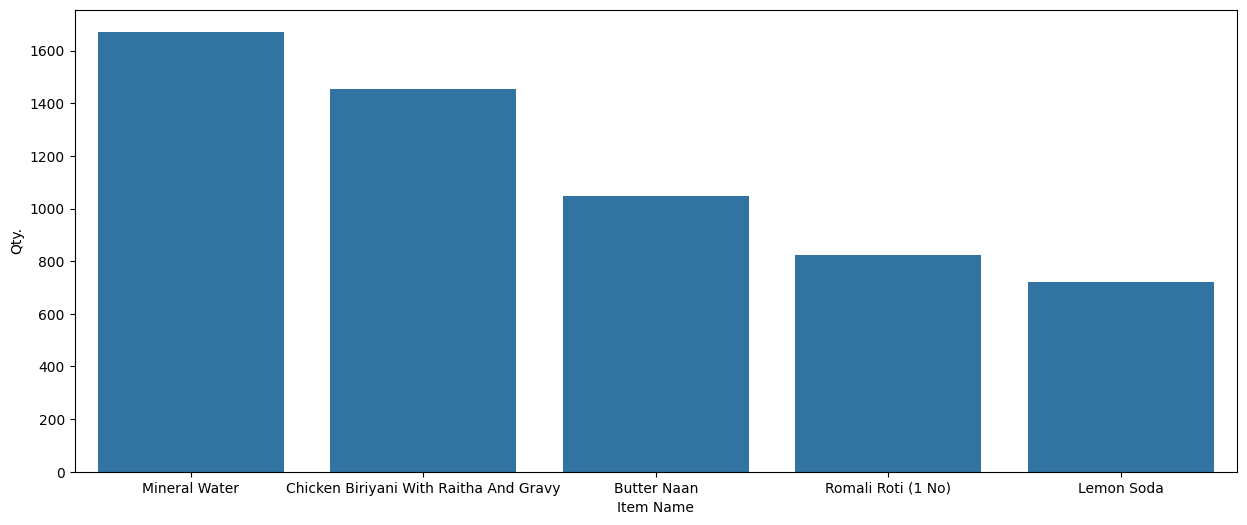

In [ ]:
plt.figure(figsize=(15,6))
sns.barplot(c)

<Axes: xlabel='Item Name'>

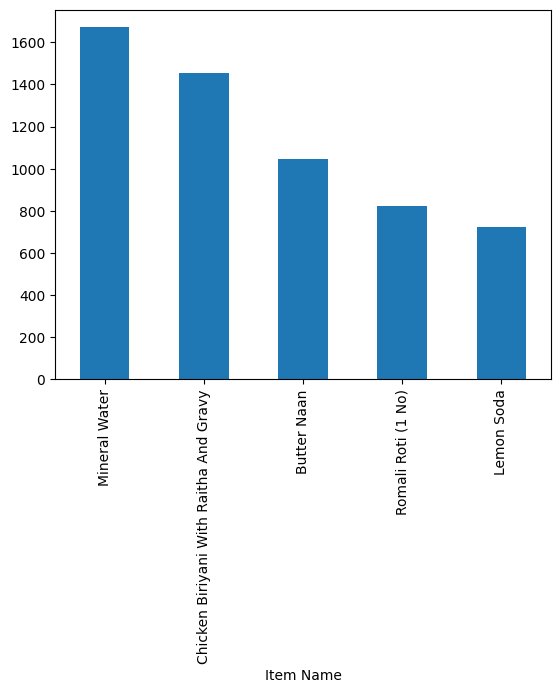

In [ ]:
c.plot(kind='bar')

In [ ]:
d=df.groupby('Item Name')['Final Total'].sum().sort_values(ascending=False)[0:10]

<Axes: xlabel='Item Name'>

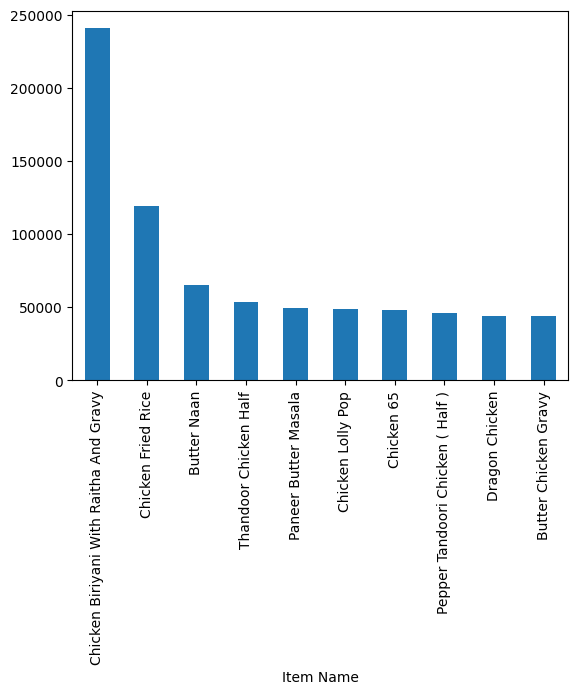

In [ ]:
d.plot(kind='bar')

In [ ]:
e = df[df['Date'] == '2023-09-15'][['Final Total']].sum()
e

,0
Final Total,21042.02


In [ ]:
e = df.groupby('Date')[['Final Total']].sum().loc['2023-09-15']
e

,2023-09-15
Final Total,21042.02


In [ ]:
f= df[(df['Date'] == '2023-09-15')&(df['Item Name']== 'Chicken Noodles')][['Qty.']].sum()
f

,0
Qty.,7.0


In [ ]:
g=df.groupby('Invoice No.')['Final Total'].sum()

In [ ]:
g[g>2000.00]

,Final Total
Invoice No.,
23499,2533.64
23508,2011.00
23637,5644.82
23718,3517.50
23827,22638.00
...,...
28014,3013.68
28126,2887.50
28145,4078.68


In [ ]:
h=df.groupby('Invoice No.')['Final Total'].sum()

In [ ]:
h[h==2887.50]

,Final Total
Invoice No.,
28126,2887.5


In [ ]:
i=df[df['Invoice No.']==28145][['Item Name','Final Total','Qty.']].sum()
i

,0
Item Name,Butter Chicken GravyButter Chicken GravyButter...
Final Total,4078.68
Qty.,40.0


In [ ]:
j = df.groupby('Invoice No.')['Final Total'].sum()[28145]
j

np.float64(4078.68)

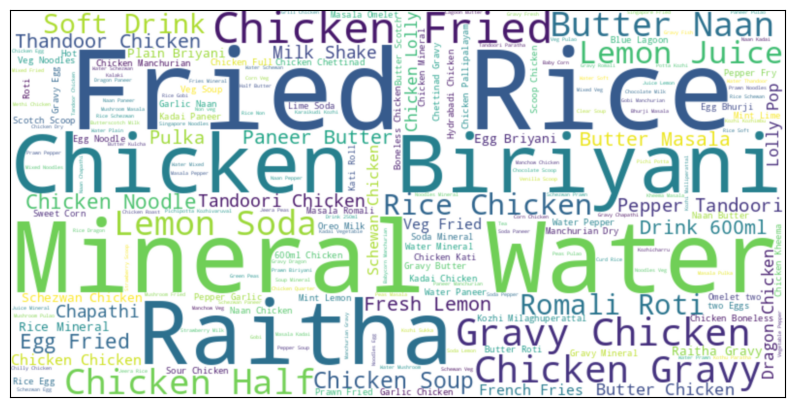

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig, ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bicubic')
ax.set_xticks([])
ax.set_yticks([])
plt.show()


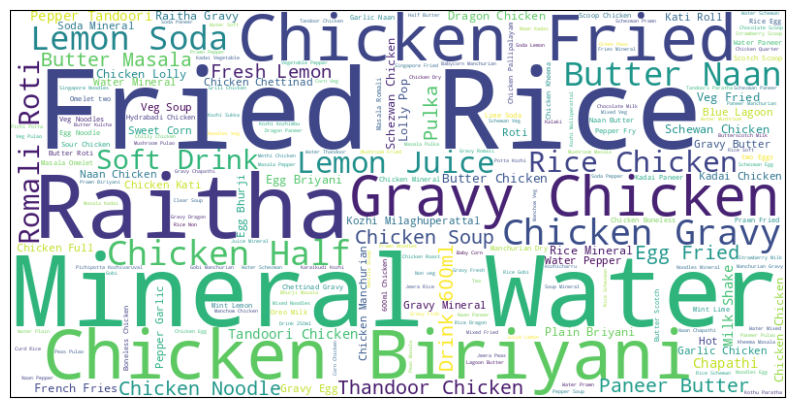

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig, ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='bilinear')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

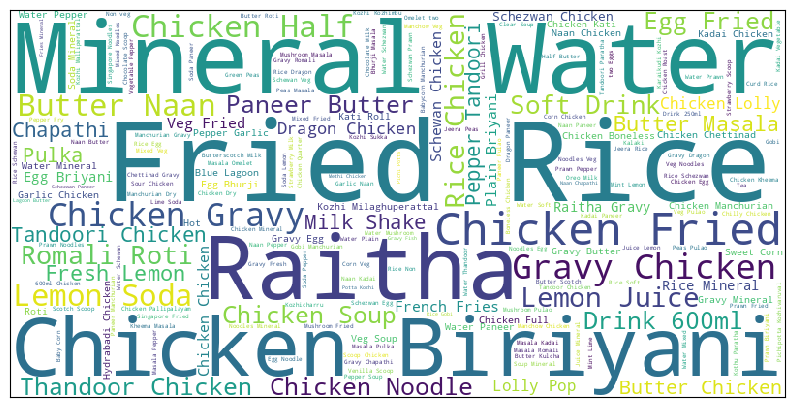

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig, ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

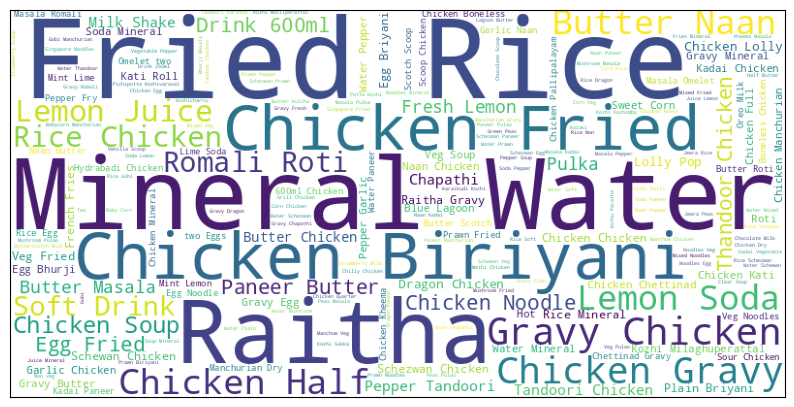

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig, ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='antialiased')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

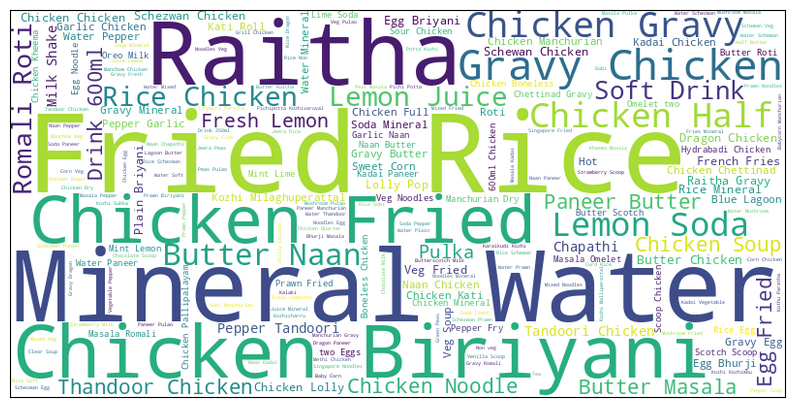

In [ ]:
from wordcloud import WordCloud
text= ' '.join(df['Item Name'].dropna().astype(str).values)
wordcloud = WordCloud(background_color='white',width=800,height=400).generate(text)
fig, ax=plt.subplots(figsize=(10,6))
ax.imshow(wordcloud,interpolation='spline36')
ax.set_xticks([])
ax.set_yticks([])
plt.show()